In [15]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset Shape:
(2000, 17)

Categorical Features:
Index(['customer_id', 'region', 'plan_type', 'contract_type',
       'payment_method'],
      dtype='str')

Numerical Features:
Index(['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='str')

Target Variable Distribution:
churn
0    1969
1      31
Name: count, dtype: int64

Missing Values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complain

C:\Users\Pranav Bhoir\AppData\Local\Temp\ipykernel_2844\3667814768.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


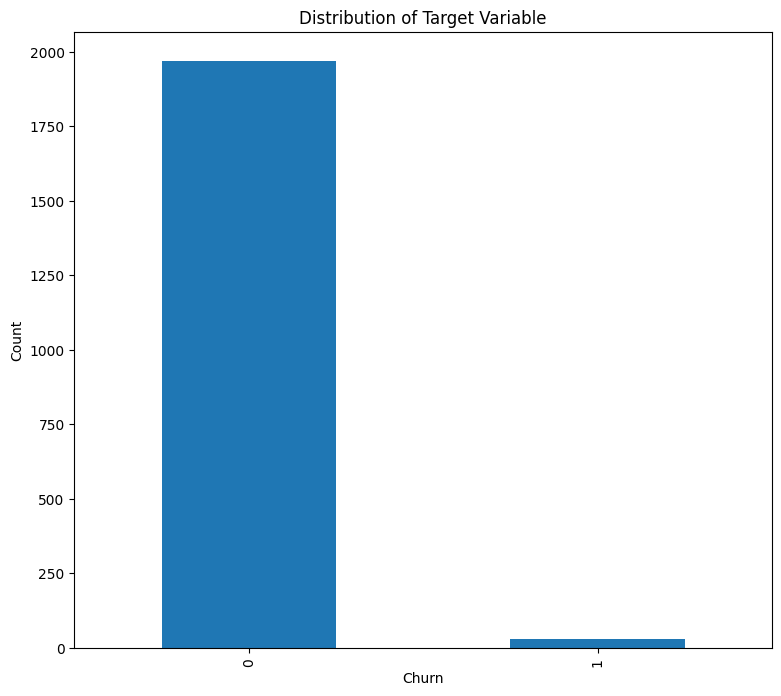

Missing Values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

Training Feature Shape: (1600, 24)
Testing Feature Shape: (400, 24)
Input Layer: 24
Hidden Layers: (32,16)
Activation Function: relu
Output Layer: Binary Classification
Loss Function: log loss
Optimizer: adam
Training Accuracy: 1.0
Training Loss: 0.0025233124182943924

Testing Accuracy: 0.975
Testing Loss: 0.1753196460746571

Confusion Matrix:
[[390   3]
 [  7   0]]


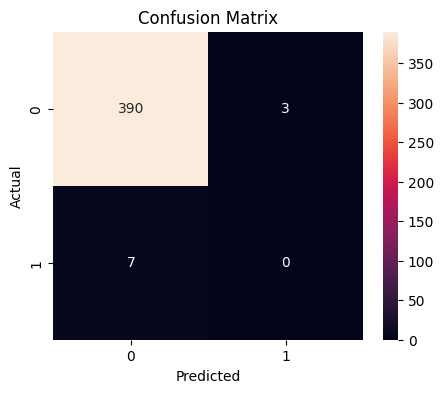

BRIEF INTERPRETATION OF THE RESULT
Greater accuracy means higher prediction accuracy.
Small loss implies effective model training.
The confusion matrix displays right and wrong predictions.


C:\Users\Pranav Bhoir\AppData\Roaming\Python\Python314\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


  Hidden Layers Activation  Iterations  Test Accuracy
0         (16,)       relu         200         0.9800
1      (32, 16)       relu         300         0.9800
2      (64, 32)       tanh         400         0.9775


In [35]:
##======TASK 1 = DATASET UNDERSTANDING==========
import pandas as pd
import matplotlib.pyplot as plt

## LOAD DATASET

df = pd.read_csv("customer_churn_nn.csv")

## NUMBER OF ROWS AND COLUMNS

print("Dataset Shape:")
print(df.shape)

## INPUT FEATURE TYPES

categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

print("\nCategorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

## TARGET VARIABLE DESCRIPTION

print("\nTarget Variable Distribution:")
print(df['churn'].value_counts())

## MISSING VALUE CHECK

print("\nMissing Values:")
print(df.isnull().sum())

## BASIC STATISTICAL SUMMARY

print("\nStatistical Summary:")
print(df.describe())

## DISTRIBUTION OF TARGET VARIABLE

plt.figure(figsize=(9,8))

df['churn'].value_counts().plot(kind='bar')

plt.title("Distribution of Target Variable")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

##=======TASK 2 = DATA PREPROCESSING==========

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## MISSING VALUES
print("Missing Values:")
print(df.isnull().sum())

df = df.drop("customer_id", axis=1)

## ENCODING CATEGORICAL FEATURE
cat_features = [
    'region',
    'plan_type',
    'contract_type',
    'payment_method'
]

df = pd.get_dummies(
    df,
    columns=cat_features,
    drop_first=True
)

X_data = df.drop("churn", axis=1)
y_data = df["churn"]

## SCALING OR NORMALIZING NUMERICAL FEATURES
scaler = StandardScaler()

scaled_features = scaler.fit_transform(X_data)

# SPLITTING INTO TRAINING AND TESTING SETS
X_train, X_test, y_train, y_test = train_test_split(
    scaled_features,
    y_data,
    test_size=0.2,
    random_state=42
)

print("\nTraining Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)

##=======TASK 3 = NEURAL NETWORK MODEL BUIDING========


from sklearn.neural_network import MLPClassifier

## INPUT LAYER
total_inputs = X_train.shape[1]

## BUILD FEED-FORWARD NEURAL NETWORK
model = MLPClassifier(
    ## HIDDEN LAYERS
    hidden_layer_sizes=(34,18),
    ## ACTIVATION FUNCTION
    activation='relu',
    ## OPTIMIZER
    solver='adam',
    ## MAXIMUM ITERATIONS
    max_iter=300,
    random_state=42
)

## TRAIN MODEL
model.fit(X_train, y_train)

## MODEL DETAILS
print("Input Layer:", total_inputs)
print("Hidden Layers: (32,16)")
print("Activation Function: relu")
print("Output Layer: Binary Classification")
print("Loss Function: log loss")
print("Optimizer: adam")

##=======TASK 4 = TAINING AND EVALUATION 

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import log_loss

import matplotlib.pyplot as plt
import seaborn as sns


train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# TRAINING ACCURACY AND LOSS
training_accuracy = accuracy_score(y_train, train_predictions)
training_loss = log_loss(y_train, model.predict_proba(X_train))

print("Training Accuracy:", training_accuracy)
print("Training Loss:", training_loss)

# TESTING ACCURACY AND LOSS
testing_accuracy = accuracy_score(y_test, test_predictions)
testing_loss = log_loss(y_test, model.predict_proba(X_test))

print("\nTesting Accuracy:", testing_accuracy)
print("Testing Loss:", testing_loss)

# CONFUSION MATRIX
conf_matrix = confusion_matrix(y_test, test_predictions)

print("\nConfusion Matrix:")
print(conf_matrix)

# PLOT CONFUSION MATRIX
plt.figure(figsize=(5,4))

sns.heatmap(conf_matrix, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("evaluation_outputs.png")

plt.show()

## BRIEF INTERPRETATION OF THE RESULT
print("BRIEF INTERPRETATION OF THE RESULT")
print("Greater accuracy means higher prediction accuracy.")
print("Small loss implies effective model training.")
print("The confusion matrix displays right and wrong predictions.")

##==========TASK 5 = HYPERPARAMETER EXPERIMENTATION=========

final_results = []

experiment_configs = [

    {
        "neurons": (16,),
        "activation": "relu",
        "iterations": 200
    },

    {
        "neurons": (32,16),
        "activation": "relu",
        "iterations": 300
    },

    {
        "neurons": (64,32),
        "activation": "tanh",
        "iterations": 400
    }
]

for setting in experiment_configs:

    neural_model = MLPClassifier(

        hidden_layer_sizes=setting["neurons"],
        activation=setting["activation"],
        solver='adam',
        max_iter=setting["iterations"],
        random_state=42
    )

    neural_model.fit(X_train, y_train)

    predicted_values = neural_model.predict(X_test)

    model_accuracy = accuracy_score(y_test, predicted_values)

    final_results.append([
        setting["neurons"],
        setting["activation"],
        setting["iterations"],
        model_accuracy
    ])

## COMPARISON TABLE
comparison_table = pd.DataFrame(final_results, columns=[
    "Hidden Layers",
    "Activation",
    "Iterations",
    "Test Accuracy"
])

print(comparison_table)

## SAVE COMPARISON TABLE
comparison_table.to_csv(
    "model_comparison_table.csv",
    index=False
)